# 08_baseline_classical_features

Evaluate the locked classical baseline model on train, validation, and independent test splits. The test set is used only for final reporting.

In [1]:

from pathlib import Path
import os, json, shutil, zipfile, hashlib, warnings, math, random, glob
from datetime import datetime, timezone
import pandas as pd
import numpy as np

BASE_DIR = Path(os.environ.get("THERMO_BASE_DIR", "/content"))
PROJECT_NAME = "project_thermography_equine"
PROJECT_ROOT = BASE_DIR / PROJECT_NAME
DATA_ROOT = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_ROOT / "raw"
SPLIT_DATA_DIR = DATA_ROOT / "dataset_split"
METADATA_DIR = DATA_ROOT / "metadata"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CONFIG_DIR = OUTPUT_ROOT / "config"
REPORTS_DIR = OUTPUT_ROOT / "reports"
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
MODELS_DIR = OUTPUT_ROOT / "models"
MODEL_SELECTION_DIR = OUTPUT_ROOT / "model_selection"
PROCESSED_DIR = DATA_ROOT / "processed"
CLEAN_IMAGE_DIR = PROCESSED_DIR / "clean_images"
FEATURES_DIR = OUTPUT_ROOT / "features"

for p in [PROJECT_ROOT, DATA_ROOT, RAW_DATA_DIR, SPLIT_DATA_DIR, METADATA_DIR, ANNOTATIONS_DIR,
          OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR,
          MODEL_SELECTION_DIR, PROCESSED_DIR, CLEAN_IMAGE_DIR, FEATURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SEARCH_ROOTS = [BASE_DIR, Path('/mnt/data')]

def _existing_roots():
    return [p for p in SEARCH_ROOTS if p.exists()]

def _safe_copy(src: Path, dst: Path, overwrite: bool = False):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if src.resolve() == dst.resolve():
        return dst
    if overwrite or not dst.exists():
        shutil.copy2(src, dst)
    return dst

def find_first(patterns, roots=None, exclude_dirs=(".ipynb_checkpoints",)):
    roots = roots or _existing_roots()
    for root in roots:
        for pattern in patterns:
            for p in sorted(root.rglob(pattern)):
                if any(part in exclude_dirs for part in p.parts):
                    continue
                if p.is_file():
                    return p
    return None

def recover_notebook06_outputs():
    """Recover outputs from Notebook 06 if the user uploaded them to /content instead of project outputs/config."""
    targets = {
        "classical_features.csv": ["classical_features.csv", "classical_features*.csv"],
        "classical_feature_metadata.json": ["classical_feature_metadata.json"],
        "classical_feature_summary.csv": ["classical_feature_summary.csv"],
    }
    recovered = {}
    for target, patterns in targets.items():
        dst = CONFIG_DIR / target
        if dst.exists():
            recovered[target] = str(dst)
            continue
        src = find_first(patterns)
        if src is None:
            recovered[target] = None
            continue
        _safe_copy(src, dst)
        if target.endswith('.csv'):
            _safe_copy(src, FEATURES_DIR / target)
        recovered[target] = str(src)
    meta_path = CONFIG_DIR / "classical_feature_metadata.json"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))

        if meta.get("clinical_label_source") == "folder_structure":
            meta["clinical_label_source"] = "expert_curated_folder_structure_based_on_clinical_assessment"
            meta["clinical_label_source_note"] = (
                "Folder structure stores labels assigned by veterinary specialists before model development; "
                "folder names are a technical representation, not an independent diagnostic criterion."
            )
            meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    return recovered

def load_classical_features_and_metadata():
    recovered = recover_notebook06_outputs()
    features_path = CONFIG_DIR / "classical_features.csv"
    metadata_path = CONFIG_DIR / "classical_feature_metadata.json"
    if not features_path.exists() or not metadata_path.exists():
        raise FileNotFoundError(
            "Notebook 06 outputs are missing. Upload classical_features.csv and classical_feature_metadata.json, "
            "or run Notebook 06 before this notebook. Recovery status: " + json.dumps(recovered, indent=2)
        )
    features = pd.read_csv(features_path)
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    feature_columns = metadata.get("feature_columns", [])
    required = {"horse_id", "split", "label_clinical", "label_binary"}
    missing_required = sorted(required - set(features.columns))
    if missing_required:
        raise KeyError("classical_features.csv is missing required columns: " + ", ".join(missing_required))
    missing_features = [c for c in feature_columns if c not in features.columns]
    if missing_features:
        raise KeyError("Feature columns listed in metadata are absent from classical_features.csv: " + ", ".join(missing_features[:20]))
    allowed_splits = {"train", "valid", "test"}
    bad_splits = sorted(set(features["split"].dropna().astype(str)) - allowed_splits)
    if bad_splits:
        raise ValueError("Unexpected split labels: " + ", ".join(bad_splits))
    overlap = []
    for a in allowed_splits:
        for b in allowed_splits:
            if a < b:
                ia = set(features.loc[features["split"] == a, "horse_id"].astype(str))
                ib = set(features.loc[features["split"] == b, "horse_id"].astype(str))
                common = ia & ib
                if common:
                    overlap.append((a, b, len(common), sorted(list(common))[:5]))
    if overlap:
        raise ValueError("Horse-level leakage detected across splits: " + repr(overlap))
    leakage_like = [c for c in feature_columns if any(token in c.lower() for token in ["hotspot", "annotation", "label", "split", "horse_id", "image_name"])]
    if leakage_like:
        raise ValueError("Potential leakage columns found among predictors: " + ", ".join(leakage_like))
    print("Project root:", PROJECT_ROOT)
    print("Config dir:", CONFIG_DIR)
    print("Loaded Notebook 06 feature table:", features.shape)
    print("Clinical label source:", metadata.get("clinical_label_source"))
    display(features.groupby(["split", "label_clinical"]).size().reset_index(name="n"))
    return features, metadata, feature_columns


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve
import joblib
import matplotlib.pyplot as plt

features, feature_metadata, feature_columns = load_classical_features_and_metadata()
model_path = MODELS_DIR / "selected_classical_model.joblib"
record_path = CONFIG_DIR / "selected_classical_model.json"
for p in [model_path, record_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}. Run Notebook 07 first.")
model = joblib.load(model_path)
selection_record = json.loads(record_path.read_text(encoding="utf-8"))
threshold = float(selection_record.get("decision_threshold", 0.5))
print("Loaded model:", selection_record["selected_model_name"])
print("Decision threshold:", threshold)


Project root: /content/project_thermography_equine
Config dir: /content/project_thermography_equine/outputs/config
Loaded Notebook 06 feature table: (347, 46)
Clinical label source: expert_classification_from_folder_structure


,split,label_clinical,n
0,test,healthy,40
1,test,pathological,13
2,train,healthy,179
3,train,pathological,63
4,valid,healthy,38
5,valid,pathological,14


Loaded model: logistic_l2
Decision threshold: 0.21214616001573788


In [5]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix

def get_prob(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))

def choose_threshold_youden(y_true, y_prob):
    # Validation-only threshold choice: maximizes sensitivity + specificity - 1.
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    candidates = np.unique(np.r_[0.0, y_prob, 1.0])
    best = {"threshold": 0.5, "youden_j": -np.inf, "balanced_accuracy": -np.inf}
    for thr in candidates:
        pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        youden = sens + spec - 1
        bal = (sens + spec) / 2
        if (youden, bal) > (best["youden_j"], best["balanced_accuracy"]):
            best = {"threshold": float(thr), "youden_j": float(youden), "balanced_accuracy": float(bal), "sensitivity": float(sens), "specificity": float(spec)}
    return best

def metric_dict(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else np.nan,
        "average_precision": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else np.nan,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "sensitivity": float(tp / (tp + fn)) if (tp + fn) else np.nan,
        "specificity": float(tn / (tn + fp)) if (tn + fp) else np.nan,
        "ppv": float(tp / (tp + fp)) if (tp + fp) else np.nan,
        "npv": float(tn / (tn + fn)) if (tn + fn) else np.nan,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


In [6]:
def metrics_for_split(df, split_name, threshold):
    if df.empty:
        raise ValueError(f"Split {split_name} is empty.")
    y = df["label_binary"].astype(int).values
    prob = get_prob(model, df[feature_columns])
    pred = (prob >= threshold).astype(int)
    md = metric_dict(y, prob, threshold=threshold)
    out = {"split": split_name, "n": int(len(df)), "n_positive": int(y.sum()), "n_negative": int((1-y).sum()), "threshold": float(threshold), **md}
    keep_cols = [c for c in ["horse_id", "image_name", "split", "label_clinical", "label_binary", "healthy_with_expert_hotspot"] if c in df.columns]
    pred_df = df[keep_cols].copy()
    pred_df["classical_probability_pathological"] = prob
    pred_df["classical_predicted_label_binary"] = pred
    return out, pred_df

metric_rows, pred_frames = [], []
for split_name in ["train", "valid", "test"]:
    df = features[features["split"] == split_name].copy()
    out, pred_df = metrics_for_split(df, split_name, threshold)
    metric_rows.append(out)
    pred_frames.append(pred_df)

classical_metrics = pd.DataFrame(metric_rows)
classical_predictions = pd.concat(pred_frames, ignore_index=True)
display(classical_metrics)


,split,n,n_positive,n_negative,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,f1,sensitivity,specificity,ppv,npv,tn,fp,fn,tp
0,train,242,63,179,0.212146,0.834087,0.637569,0.520661,0.670834,0.516667,0.984127,0.357542,0.350282,0.984615,64,115,1,62
1,valid,52,14,38,0.212146,0.798872,0.518636,0.519231,0.671053,0.528302,1.000000,0.342105,0.358974,1.000000,13,25,0,14
2,test,53,13,40,0.212146,0.892308,0.773189,0.433962,0.625000,0.464286,1.000000,0.250000,0.302326,1.000000,10,30,0,13


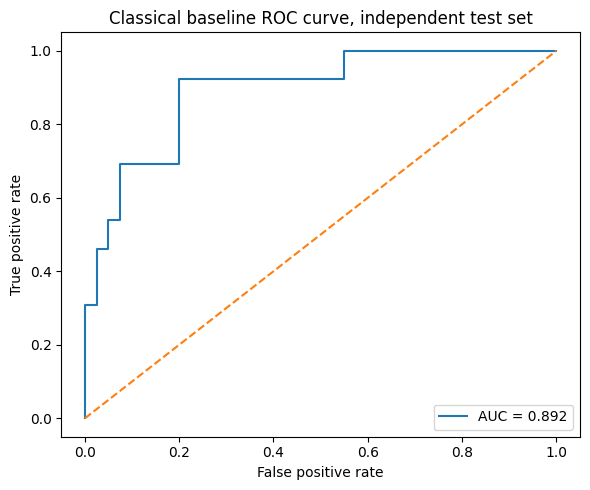

Classical baseline models were selected using the predefined training and validation sets only. The selected model was logistic_l2. The decision threshold was selected on the validation set using the Youden index (threshold=0.212146) and then applied unchanged to the independent test set. Expert hotspot annotations and healthy-with-hotspot flags were retained for reporting but excluded from model predictors.


In [7]:
classical_metrics.to_csv(CONFIG_DIR / "classical_baseline_metrics.csv", index=False)
classical_metrics.to_csv(REPORTS_DIR / "classical_baseline_metrics.csv", index=False)
classical_metrics.to_csv(TABLES_DIR / "table_classical_baseline_metrics.csv", index=False)
classical_predictions.to_csv(CONFIG_DIR / "classical_baseline_predictions.csv", index=False)
classical_predictions.to_csv(REPORTS_DIR / "classical_baseline_predictions.csv", index=False)

# ROC plot for the independent test set.
test_df = features[features["split"] == "test"].copy()
y_test = test_df["label_binary"].astype(int).values
prob_test = get_prob(model, test_df[feature_columns])
fpr, tpr, _ = roc_curve(y_test, prob_test)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, prob_test):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Classical baseline ROC curve, independent test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_classical_baseline_test_roc.png", dpi=300)
plt.show()

methods_text = (
    "Classical baseline models were selected using the predefined training and validation sets only. "
    f"The selected model was {selection_record['selected_model_name']}. The decision threshold was selected on the validation set "
    f"using the Youden index (threshold={threshold:.6f}) and then applied unchanged to the independent test set. "
    "Expert hotspot annotations and healthy-with-hotspot flags were retained for reporting but excluded from model predictors."
)
(CONFIG_DIR / "methods_classical_baseline_text.txt").write_text(methods_text, encoding="utf-8")
(REPORTS_DIR / "methods_classical_baseline_text.txt").write_text(methods_text, encoding="utf-8")
print(methods_text)
